#Libraries

In [101]:
import pandas as pd
import numpy as np

#Connect to GitHub and drive

In [102]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Data-computation-project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Data-computation-project


In [103]:
df = pd.read_csv('data/hotel_bookings.csv')

In [104]:
!ls

app.py	data  Data_computation_project.ipynb  README.md


In [100]:
!git add Data_computation_project.ipynb
!git commit -m "Added my personal copy of the notebook to the repository"
!git push origin main

[main 5075bbf] Added my personal copy of the notebook to the repository
 1 file changed, 1 insertion(+)
 create mode 100644 Data_computation_project.ipynb
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 612.33 KiB | 4.98 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/MariamKhaled741/Data-computation-project.git
   6df5bb4..5075bbf  main -> main


#Dataset Overview

#EDA

#Data Cleaning

#Dimensionality Reduction

#SVM and pipeline

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [14]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

df['arrival_date_month'] = df['arrival_date_month'].map(month_map)

In [15]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [16]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,6.552483,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,3.090619,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,4.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,7.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,9.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,12.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [17]:
df['babies'].value_counts()/len(df)*100

,count
babies,
0,99.231929
1,0.753832
2,0.012564
10,0.000838
9,0.000838


drop babies(Quasi_constant)

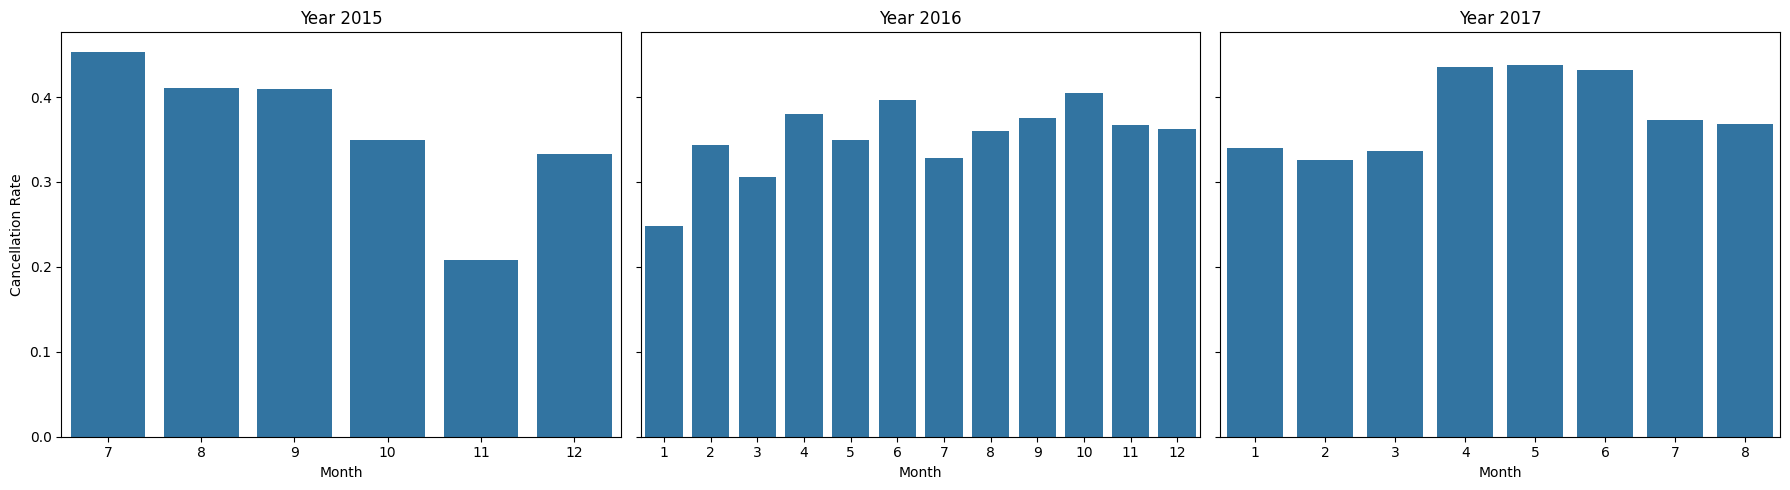

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

years = sorted(df['arrival_date_year'].unique())

fig, axes = plt.subplots(1, len(years), figsize=(18,5), sharey=True)

for i, year in enumerate(years):
    data = df[df['arrival_date_year'] == year]

    monthly_rate = data.groupby('arrival_date_month')['is_canceled'].mean().reset_index()

    sns.barplot(
        data=monthly_rate,
        x='arrival_date_month',
        y='is_canceled',
        ax=axes[i]
    )

    axes[i].set_title(f"Year {year}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Cancellation Rate")

plt.tight_layout()
plt.show()

In [19]:
df[['arrival_date_week_number','arrival_date_year','arrival_date_month']].corr()

,arrival_date_week_number,arrival_date_year,arrival_date_month
arrival_date_week_number,1.000000,-0.540561,0.995105
arrival_date_year,-0.540561,1.000000,-0.527739
arrival_date_month,0.995105,-0.527739,1.000000


dfop arrival_date_week_number	multicollinearity

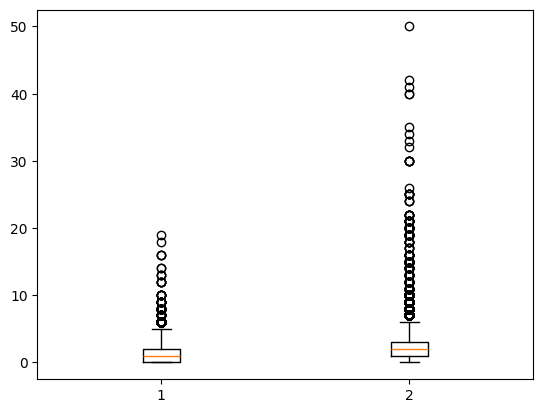

In [20]:
plt.boxplot(df[['stays_in_weekend_nights','stays_in_week_nights']])
plt.show()

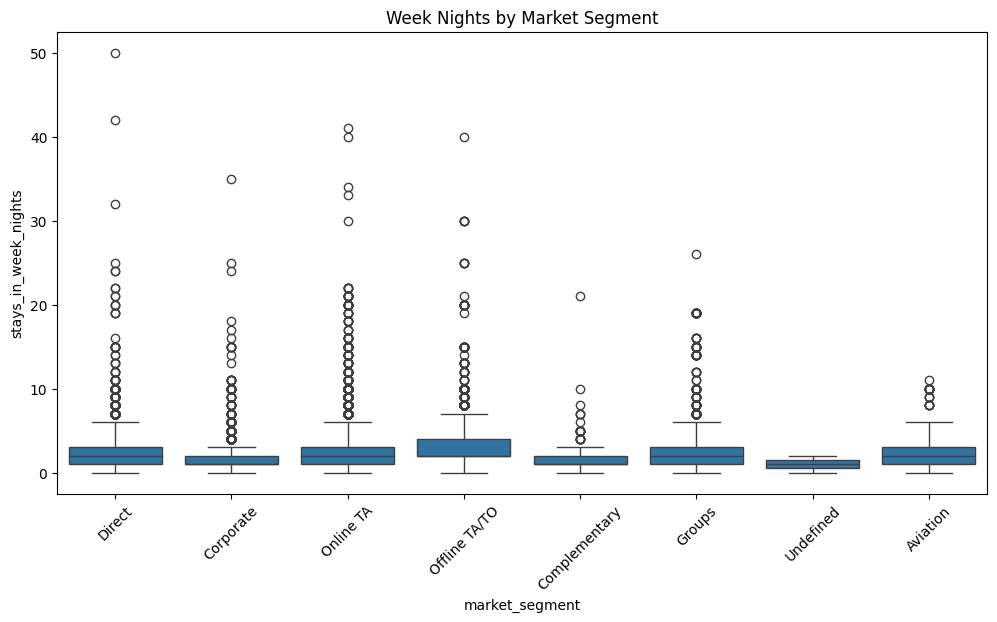

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='market_segment', y='stays_in_week_nights')

plt.xticks(rotation=45)
plt.title('Week Nights by Market Segment')
plt.show()

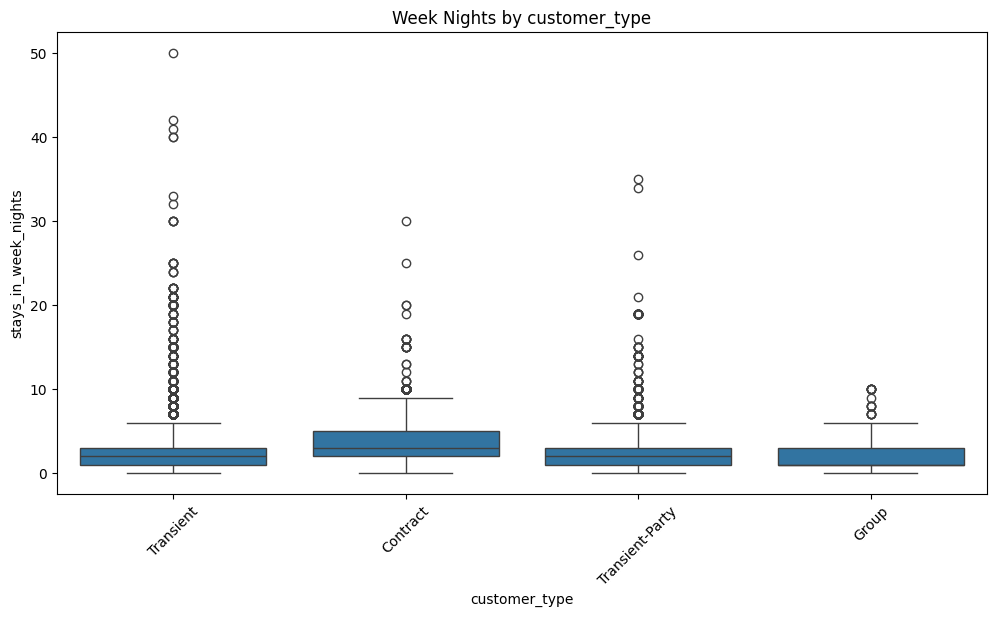

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='customer_type', y='stays_in_week_nights')

plt.xticks(rotation=45)
plt.title('Week Nights by customer_type')
plt.show()

In [23]:
vals = df['customer_type'].unique()

for val in vals:
    q = df[df['customer_type'] == val]['stays_in_week_nights'].quantile(0.99)
    print(val, q)

Transient 10.0
Contract 10.0
Transient-Party 7.0
Group 10.0


In [24]:
vals = df['market_segment'].unique()

for val in vals:
    q = df[df['market_segment'] == val]['stays_in_week_nights'].quantile(0.99)
    print(val, q)

Direct 10.0
Corporate 9.0600000000004
Online TA 9.0
Offline TA/TO 10.0
Complementary 5.0
Groups 7.0
Undefined 1.98
Aviation 10.0


In [25]:
df['stays_in_weekend_nights'].quantile(0.99)

np.float64(4.0)

In [26]:
df['stays_in_week_nights'].quantile(0.99)

np.float64(10.0)

capping / winsorizing

problem    stays_in_weekend_nights&stays_in_week_nights=0

In [27]:
df[(df['stays_in_weekend_nights'] == 0) &
   (df['stays_in_week_nights'] == 0)]['meal'].value_counts()

,count
meal,
BB,550
SC,79
HB,76
Undefined,9
FB,1


In [28]:
df.groupby('customer_type')['adults'].value_counts()

customer_type    adults
Contract         2          3635
                 1           377
                 3            59
                 0             5
Group            2           368
                 1           172
                 3            17
                 26            5
                 0             4
                 5             2
                 20            2
                 27            2
                 6             1
                 10            1
                 40            1
                 50            1
                 55            1
Transient        2         68433
                 1         15278
                 3          5567
                 0           276
                 4            59
Transient-Party  2         17244
                 1          7200
                 3           559
                 0           118
                 4             3
Name: count, dtype: int64

problem 0,0,0 (cell19:cell23)

In [29]:
df[(df['adults']==0)&(df['children']==0)]['reserved_room_type'].value_counts()

,count
reserved_room_type,
A,121
D,22
E,16
P,12
F,3
B,3
G,2
C,1


In [30]:
df[(df['adults']==0)&(df['children']!=0)]['reserved_room_type'].value_counts()

,count
reserved_room_type,
B,208
A,10
F,2
G,1
E,1
D,1


In [31]:
df[(df['adults']==0)&(df['children']!=0)]['market_segment'].value_counts()

,count
market_segment,
Online TA,187
Direct,29
Complementary,4
Offline TA/TO,3


In [32]:
df['market_segment'].value_counts()

,count
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2


In [33]:
df['reserved_room_type'].value_counts()

,count
reserved_room_type,
A,85994
D,19201
E,6535
F,2897
G,2094
B,1118
C,932
H,601
P,12


In [34]:
df['children'].value_counts()/len(df)

,count
children,
0.0,0.928017
1.0,0.040715
2.0,0.030589
3.0,0.000637
10.0,0.000008


In [35]:
df[df['children']==10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
328,Resort Hotel,1,55,2015,7,29,12,4,10,2,10.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,2,No Deposit,8.0,NaN,0,Contract,133.16,0,1,No-Show,2015-07-12


In [36]:
df['children'].isna().sum()

np.int64(4)

In [37]:
df[df['children'].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,8,32,3,1,0,2,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,8,32,5,0,2,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,8,32,5,0,2,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,8,33,13,2,5,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


capping / winsorizing  
fillna with median

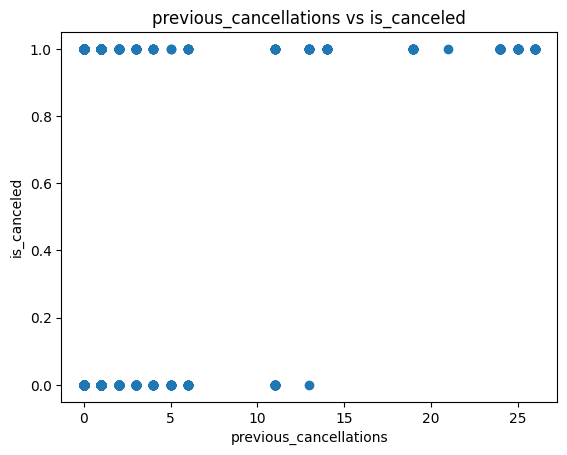

In [38]:
plt.figure()
plt.scatter(df['previous_cancellations'], df['is_canceled'])

plt.xlabel('previous_cancellations')
plt.ylabel('is_canceled')
plt.title('previous_cancellations vs is_canceled')

plt.show()

In [39]:
df.groupby('customer_type')['previous_cancellations'].value_counts()

customer_type    previous_cancellations
Contract         0                          3158
                 1                           917
                 2                             1
Group            0                           558
                 1                            17
                 2                             2
Transient        0                         86021
                 1                          3241
                 2                            95
                 3                            53
                 4                            29
                 26                           26
                 11                           25
                 25                           25
                 24                           24
                 6                            22
                 19                           19
                 5                            18
                 14                           14
                 13                            1
Transient-Party  0                         23169
                 1                          1876
                 24                           24
                 2                            18
                 3                            12
                 13                           11
                 11                           10
                 4                             2
                 5                             1
                 21                            1
Name: count, dtype: int64

In [40]:
df['company'] = df['company'].fillna('No_Company')

In [41]:
company_map = df.groupby('company')['is_canceled'].mean()

df['company_cancel_rate'] = df['company'].map(company_map)

In [42]:
df['agent'] = df['agent'].fillna('No_agent')

In [43]:
agent_map = df.groupby('agent')['is_canceled'].mean()

df['agent_cancel_rate'] = df['agent'].map(agent_map)

In [44]:
df=df.drop(['agent','company'],axis=1)

drop agent,company

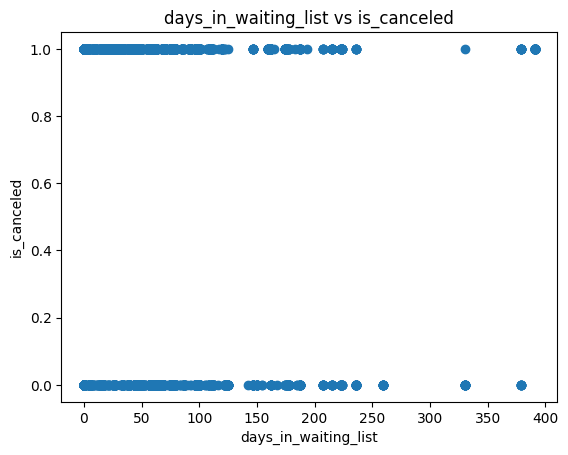

In [45]:
plt.figure()
plt.scatter(df['days_in_waiting_list'], df['is_canceled'])

plt.xlabel('days_in_waiting_list')
plt.ylabel('is_canceled')
plt.title('days_in_waiting_list vs is_canceled')

plt.show()

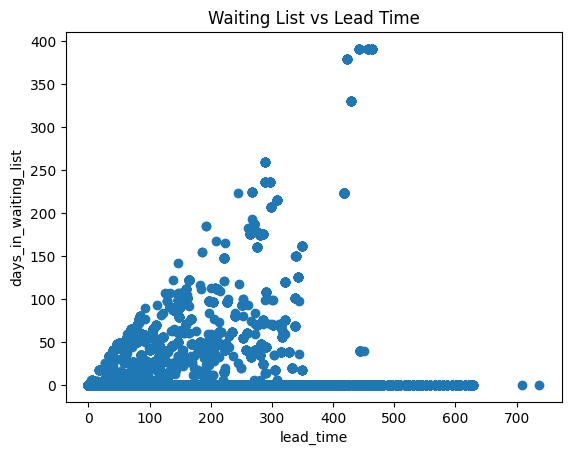

In [46]:
plt.figure()
plt.scatter(df['lead_time'], df['days_in_waiting_list'])
plt.xlabel('lead_time')
plt.ylabel('days_in_waiting_list')
plt.title('Waiting List vs Lead Time')
plt.show()

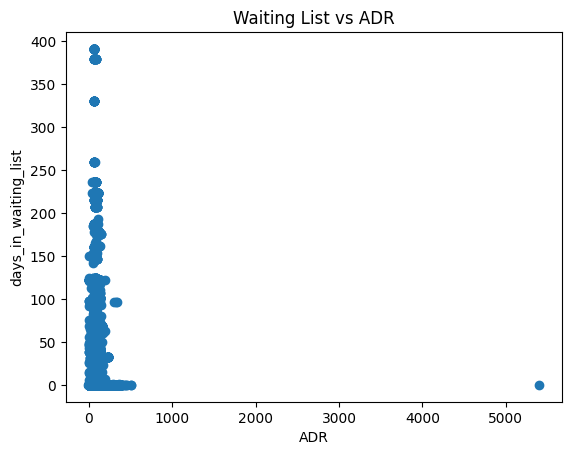

In [47]:
plt.figure()
plt.scatter(df['adr'], df['days_in_waiting_list'])
plt.xlabel('ADR')
plt.ylabel('days_in_waiting_list')
plt.title('Waiting List vs ADR')
plt.show()

capping / winsorizing

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


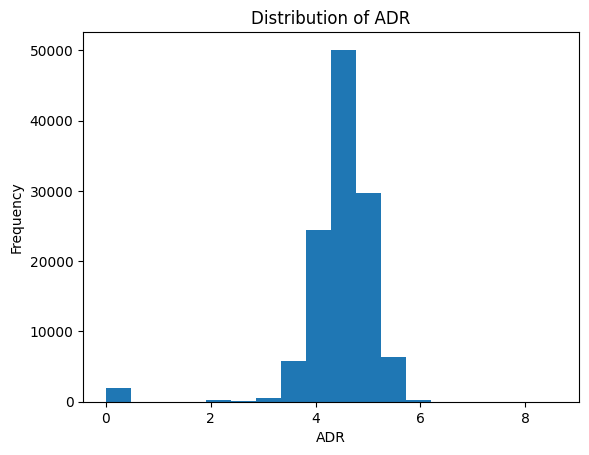

In [48]:
plt.figure()
plt.hist(np.log1p(df['adr']), bins=18)
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.title('Distribution of ADR')
plt.show()

In [49]:
df[df['adr']<0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,company_cancel_rate,agent_cancel_rate
14969,Resort Hotel,0,195,2017,3,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,0.3822,0.346705


In [50]:
df['adr'].quantile(0.99)

np.float64(252.0)

In [51]:
df[(df['adr']==0)&((df['stays_in_week_nights']!=0)|(df['stays_in_weekend_nights']!=0))&(df['is_canceled']==0)]['market_segment'].value_counts()

,count
market_segment,
Complementary,574
Groups,193
Offline TA/TO,146
Direct,77
Online TA,50
Corporate,26


In [52]:
df['room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

In [53]:
df[(df['adr']==0)&((df['stays_in_week_nights']!=0)|(df['stays_in_weekend_nights']!=0))&(df['is_canceled']==0)]['room_changed'].value_counts()

,count
room_changed,
0,662
1,404


In [54]:
df['room_changed'].value_counts()

,count
room_changed,
0,104473
1,14917


capping / winsorizing
 ve -> 0

In [55]:
df['required_car_parking_spaces'].quantile(0.99)

np.float64(1.0)

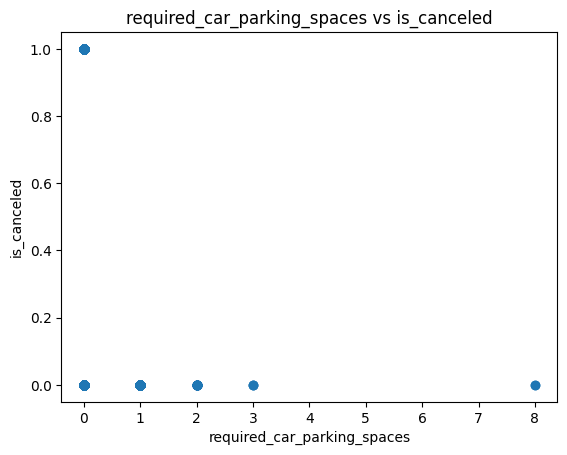

In [56]:
plt.figure()
plt.scatter(df['required_car_parking_spaces'], df['is_canceled'])

plt.xlabel('required_car_parking_spaces')
plt.ylabel('is_canceled')
plt.title('required_car_parking_spaces vs is_canceled')

plt.show()

In [57]:
df[df['required_car_parking_spaces']==8]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,company_cancel_rate,agent_cancel_rate,room_changed
29045,Resort Hotel,0,26,2017,3,11,14,0,5,2,0.0,0,HB,AUT,Direct,Corporate,1,0,2,E,I,1,No Deposit,0,Transient-Party,40.0,8,1,Check-Out,2017-03-19,0.3822,0.246634,1
29046,Resort Hotel,0,138,2017,3,12,19,2,2,2,0.0,0,HB,AUT,Direct,Corporate,1,0,2,E,F,1,No Deposit,122,Transient-Party,80.0,8,0,Check-Out,2017-03-23,0.3822,0.246634,1


In [58]:
df['has_parking'] = (df['required_car_parking_spaces'] > 0).astype(int)

In [59]:
df[['required_car_parking_spaces','has_parking','is_canceled']].corr(method='spearman')

,required_car_parking_spaces,has_parking,is_canceled
required_car_parking_spaces,1.000000,0.999991,-0.197397
has_parking,0.999991,1.000000,-0.197399
is_canceled,-0.197397,-0.197399,1.000000


replace required_car_parking_spaces , has_parking





In [60]:
df['total_of_special_requests'].quantile(0.99)

np.float64(3.0)

<Axes: xlabel='total_of_special_requests'>

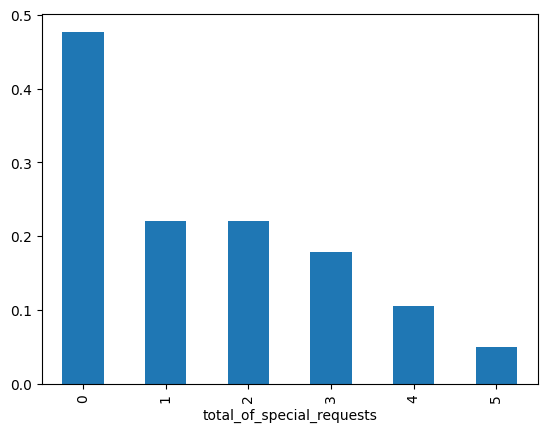

In [61]:
df.groupby('total_of_special_requests')['is_canceled'].mean().plot(kind='bar')


In [62]:
df['total_of_special_requests'].value_counts()/len(df)*100

,count
total_of_special_requests,
0,58.897730
1,27.829801
2,10.862719
3,2.091465
4,0.284781
5,0.033504


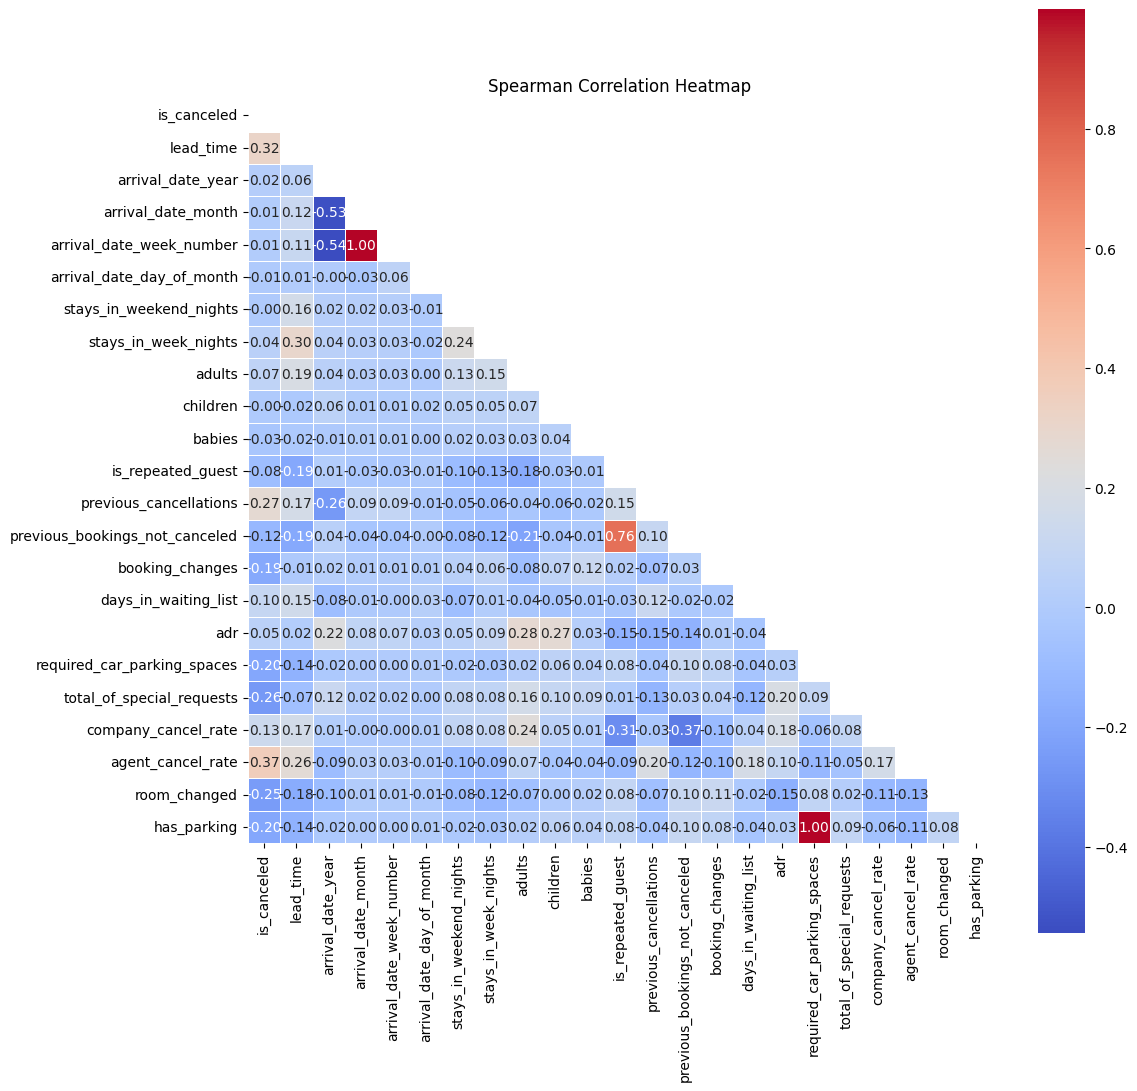

In [63]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr(method='spearman')


mask = np.triu(np.ones_like(corr, dtype=bool))


plt.figure(figsize=(12, 12))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap")
plt.show()

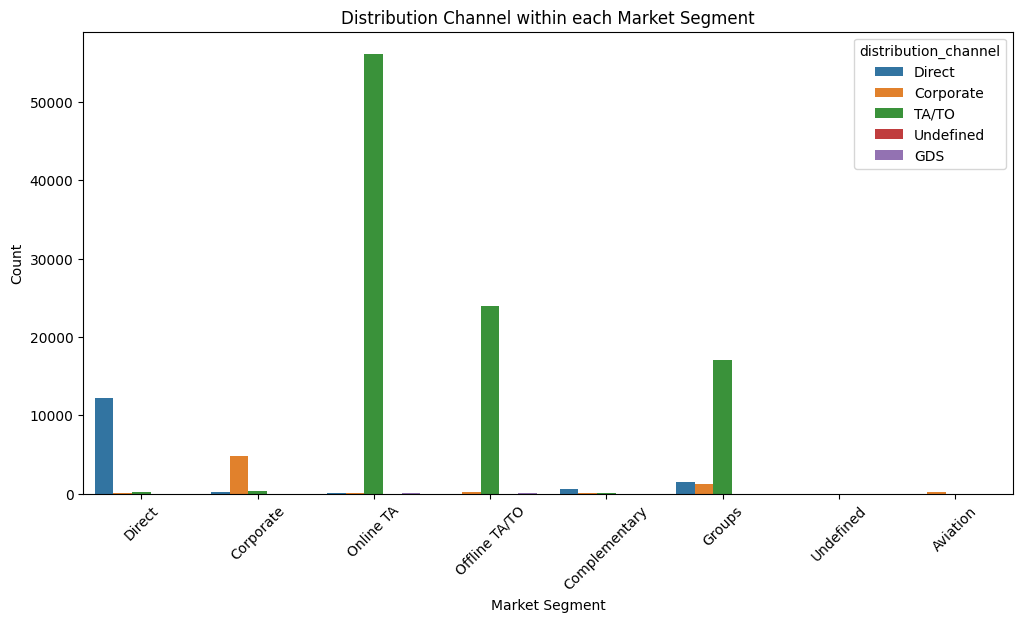

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.countplot(data=df, x='market_segment', hue='distribution_channel')

plt.xlabel('Market Segment')
plt.ylabel('Count')
plt.title('Distribution Channel within each Market Segment')
plt.xticks(rotation=45)
plt.show()

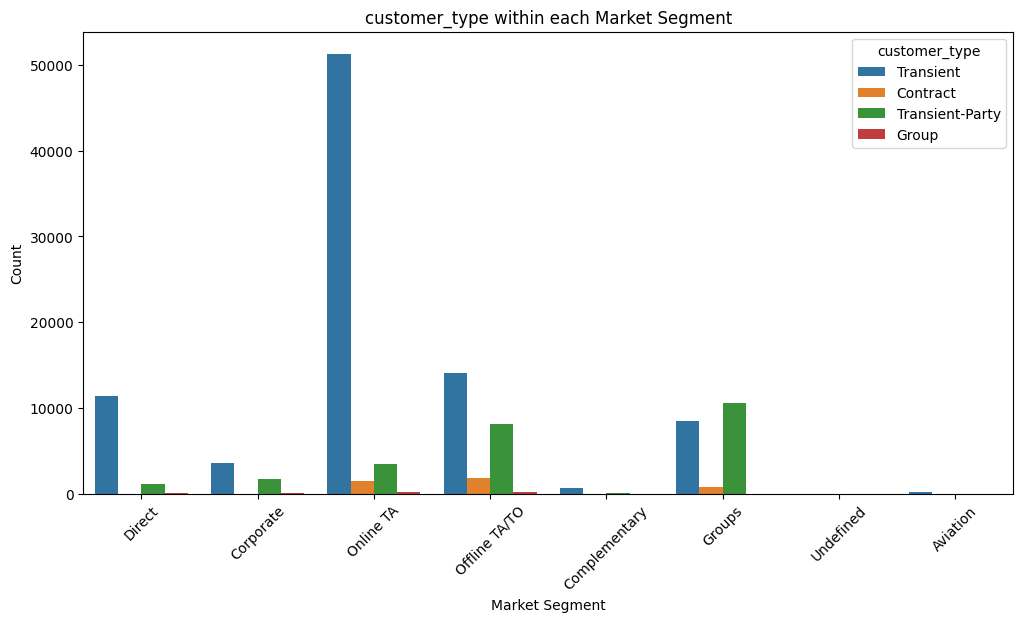

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.countplot(data=df, x='market_segment', hue='customer_type')

plt.xlabel('Market Segment')
plt.ylabel('Count')
plt.title('customer_type within each Market Segment')
plt.xticks(rotation=45)
plt.show()

In [66]:
from sklearn.metrics import normalized_mutual_info_score

x=df['country'].fillna('Unknown')
nmi = normalized_mutual_info_score(x, df['is_canceled'])
print(nmi)

0.04322898953672811


In [67]:
from sklearn.metrics import normalized_mutual_info_score
cat_cols = ['market_segment', 'distribution_channel', 'customer_type','hotel',
            'deposit_type', 'hotel', 'meal','reserved_room_type','assigned_room_type']


for col in cat_cols:
 nmi = normalized_mutual_info_score(df[col], df['is_canceled'])
 print(f"{col}: {nmi}")

market_segment: 0.03571117858727607
distribution_channel: 0.027334547385961267
customer_type: 0.014582631306169096
hotel: 0.014709667738182157
deposit_type: 0.2516944986876126
hotel: 0.014709667738182157
meal: 0.0017947421711796672
reserved_room_type: 0.00342883259256221
assigned_room_type: 0.023326905131284537


In [68]:
n = normalized_mutual_info_score(df['booking_changes'], df['is_canceled'])
print(n)

0.03260836676795666


In [69]:
n2= normalized_mutual_info_score(df['market_segment'], df['distribution_channel'])
print(n2)

0.44403773333104346


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV

In [72]:
df = df.drop('babies', axis=1)

In [73]:
def fix_adr(X):
    X = X.copy()
    X['adr'] = X['adr'].clip(lower=0)
    return X

In [74]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# 2. ثانياً: نحسب الـ Rate من الـ X_train و y_train فقط
# إحنا بنقول للجهاز: "تعلم نسبة الإلغاء من بيانات التدريب دي بس"
country_map = pd.concat([X_train, y_train], axis=1).groupby('country')['is_canceled'].mean()

# 3. ثالثاً: نطبق اللي اتعلمناه على الـ Train والـ Test
X_train['country_cancel_rate'] = X_train['country'].map(country_map)

# هنا بقى الذكاء: لو ظهرت دولة في الـ Test مش موجودة في الـ Train، بنعوض بمتوسط الإلغاء العام
X_test['country_cancel_rate'] = X_test['country'].map(country_map).fillna(y_train.mean())

In [ ]:
df['country'] = df['country'].fillna('Unknown')
country_map = df.groupby('country')['is_canceled'].mean()
df['country_cancel_rate'] = df['country'].map(country_map)

In [75]:
drop_cols = [
    'required_car_parking_spaces',
    'distribution_channel',
    'hotel',
    'meal',
    'assigned_room_type',
    'reserved_room_type',
    'country',
    'customer_type',
    'arrival_date_week_number'
]

cat_cols = ['market_segment', 'deposit_type']

num_cols = [
    'lead_time',
    'arrival_date_year',
    'arrival_date_day_of_month',
    'stays_in_week_nights',
    'stays_in_weekend_nights',
    'adults',
    'children',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'is_repeated_guest',
    'total_of_special_requests'
]

In [76]:
numeric_pipeline = Pipeline(steps=[
    ('fix_adr', FunctionTransformer(fix_adr)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols),
        ('drop', 'drop', drop_cols)
    ]
)

In [77]:
X_train_trans = preprocess.fit_transform(X_train)
X_test_trans = preprocess.transform(X_test)

In [78]:
logreg = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=10000,
    C=0.01
)

logreg.fit(X_train_trans, y_train)

LogisticRegression(C=0.01, max_iter=10000, penalty='l1', solver='saga')

In [79]:
mask = logreg.coef_[0] != 0

In [80]:
X_train_selected = X_train_trans[:, mask]
X_test_selected = X_test_trans[:, mask]

 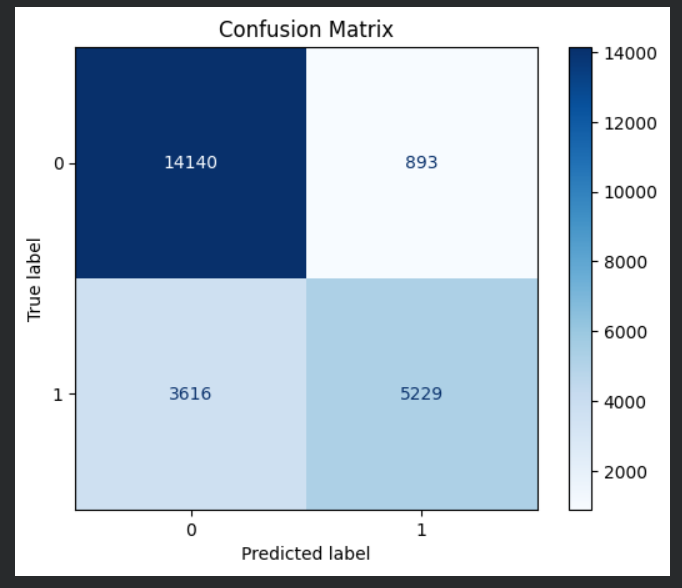

In [81]:
# ✅ Step 3: PCA - Dimensionality Reduction (الجديد)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # محتفظ بـ 95% من المعلومات
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

print(f"عدد الـ features قبل PCA: {X_train_selected.shape[1]}")
print(f"عدد الـ features بعد PCA: {X_train_pca.shape[1]}")
print(f"Explained Variance: {sum(pca.explained_variance_ratio_)*100:.2f}%")

عدد الـ features قبل PCA: 18
عدد الـ features بعد PCA: 13
Explained Variance: 95.95%


In [82]:
param_grid = [

    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.01]
    }

]

In [85]:

from sklearn.model_selection import RandomizedSearchCV

grid = RandomizedSearchCV(
    SVC(),
    param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=3,
    random_state=42
)
grid.fit(X_train_pca, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
grid.fit(X_train_pca, y_train)

best_model = SVC(kernel='rbf', gamma='scale', C=10)
best_model.fit(X_train_pca, y_train)

y_pred = best_model.predict(X_test_pca)  # X_test_pca

In [ ]:
print("Best Params:", grid.best_params_)

In [ ]:
best_model = SVC(kernel='rbf', gamma='scale', C=10)
best_model.fit(X_train_selected, y_train)

y_pred = best_model.predict(X_test_pca)
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_scores = best_model.decision_function(X_test_selected)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [ ]:
num_features = num_cols

In [ ]:
cat_features = list(
    preprocess.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_cols)
)

In [ ]:
all_features = np.array(num_features + cat_features)

In [ ]:
selected_features = all_features[mask]

In [ ]:
selected_features

In [ ]:
dropped_features = all_features[~mask]

In [ ]:
dropped_features

In [ ]:
import joblib

# حفظ الموديل والـ Pipeline والـ PCA
joblib.dump(preprocess, 'svm_pipeline.pkl')
joblib.dump(pca, 'pca_model.pkl')
joblib.dump(best_model, 'final_svm_model.pkl')
joblib.dump(mask, 'feature_mask.pkl')

print("All models saved successfully for Deployment!")